In [161]:
import pandas as pd

df = pd.read_csv("NIST DATABASE.csv")

# Separate features and labels
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [162]:
df.head()
df.iloc[:, -1].value_counts()

1
2    170
3    111
1     79
4     50
5     50
Name: count, dtype: int64

In [163]:
y

0      1
1      1
2      1
3      1
4      1
      ..
455    5
456    5
457    5
458    5
459    5
Name: 1, Length: 460, dtype: int64

In [164]:
mapping = {1:0, 2:1, 3:2, 4:3, 5:4}
y = y.map(mapping)

In [165]:
x.shape

(460, 152)

In [166]:
y.isnull().sum()


np.int64(0)

In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [168]:
# ✅ FIX (ADD HERE)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [169]:
import numpy as np

def flann_expand(x):
    return np.hstack([
        x,
        np.sin(x),
        np.cos(x),
        x**2
    ])

X_train = flann_expand(X_train)
X_test = flann_expand(X_test)

In [170]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("Final Features:", X_train.shape[1])

Final Features: 215


In [171]:
import random
from sklearn.metrics import accuracy_score

# Softmax
def softmax(z):
    z = np.clip(z, -50, 50)
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# Initialize population
def init_population(pop_size, n_features, n_classes):
    population = []

    for _ in range(pop_size):
        W = W_init + np.random.randn(*W_init.shape) * 0.01
        b = b_init + np.random.randn(*b_init.shape) * 0.01
        population.append((W, b))

    return population


# Fitness
def fitness(individual, X, y):
    W, b = individual

    # 🔥 Non-linearity
    logits = np.dot(X, W) + b
    probs = softmax(logits)
    preds = np.argmax(probs, axis=1)

    # 🔥 DEBUG (ADD HERE)
    if np.random.rand() < 0.01:
        print("Pred classes:", np.unique(preds))

    # 🔥 Regularization
    reg = 0.02 * np.mean(W**2)

    return accuracy_score(y, preds) - reg


# Selection
def select(population, fitnesses):
    idx = np.argsort(fitnesses)[-len(population)//2:]
    return [population[i] for i in idx]


# Crossover
def crossover(p1, p2):
    W1, b1 = p1
    W2, b2 = p2

    alpha = np.random.rand()

    W = alpha * W1 + (1 - alpha) * W2
    b = alpha * b1 + (1 - alpha) * b2

    return (W, b)


# Mutation
def mutate(individual, rate=0.1):
    W, b = individual

    W = W + np.random.randn(*W.shape) * .05
    b = b + np.random.randn(*b.shape) * .05

    return (W, b)

In [172]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

W_init = model.coef_.T
b_init = model.intercept_.reshape(1, -1)

In [173]:
def genetic_algorithm(X, y, generations=80, pop_size=80, mutation_rate=0.3):

    # 🔥 FORCE NUMPY (permanent fix)
    X = np.array(X)
    y = np.array(y)

    n_features = X.shape[1]
    n_classes = len(np.unique(y))

    population = init_population(pop_size, n_features, n_classes)

    best_global = None
    best_score = -np.inf

    for gen in range(generations):

        # shuffle
        idx = np.random.permutation(len(X))
        X = X[idx]
        y = y[idx]

        fitnesses = [fitness(ind, X[:150], y[:150]) for ind in population]

        best_idx = np.argmax(fitnesses)
        current_best = fitnesses[best_idx]

        print(f"Gen {gen} | Best Accuracy: {current_best:.4f}")

        # update best
        if current_best > best_score:
            best_score = current_best
            best_global = population[best_idx]
            
            if gen > 30 and abs(current_best - best_score) < 0.0001:
                print("Early stopping")
            break

        selected = select(population, fitnesses)

        new_population = []

        # elitism
        new_population.append(best_global)

        while len(new_population) < pop_size:

            # random restart (VERY IMPORTANT)
            if np.random.rand() < 0.1:
                new_population.append(
                    init_population(1, n_features, n_classes)[0]
                )
                continue

            p1, p2 = random.sample(selected, 2)
            child = crossover(p1, p2)
            child = mutate(child, mutation_rate)

            new_population.append(child)

        population = new_population

    return best_global

In [174]:
best_weights = genetic_algorithm(
    X_train,
    y_train,
    generations=120,
    pop_size=100,
    mutation_rate=0.1
)

Gen 0 | Best Accuracy: 0.9998


In [175]:
def predict(individual, X):
    W, b = individual

    logits = np.dot(X, W) + b
    probs = softmax(logits)

    return np.argmax(probs, axis=1)


y_pred = predict(best_weights, X_test)

In [176]:
from sklearn.metrics import accuracy_score

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))

Final Test Accuracy: 0.8369565217391305


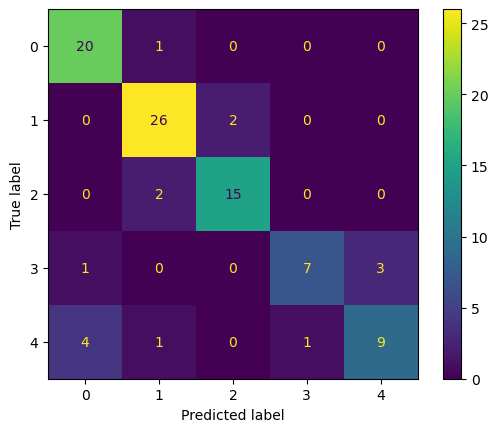

In [177]:
##for flann + ga

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()